# sin / sinf / __sinf on the GPU: accuracy and speed

**Before running:** Runtime → Change runtime type → **GPU** (T4 is fine).

Task: fill `arr[i] = sin((i%360)*Pi/180)` for 10^9 elements on the GPU, copy to host, compute `err = sum|ref - arr[i]| / 10^9`; compare `sin`, `sinf`, `__sinf` for `float` and `double` arrays, accuracy and time.

.

In [ ]:
!nvidia-smi
!nvcc --version

Tue Oct  6 09:21:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

###  CUDA source

In [ ]:
%%writefile sin_study.cu
#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <algorithm>

#define CUDA_CHECK(call)                                                        \
    do {                                                                        \
        cudaError_t e_ = (call);                                                \
        if (e_ != cudaSuccess) {                                                \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,       \
                    cudaGetErrorString(e_));                                    \
            exit(1);                                                            \
        }                                                                       \
    } while (0)

constexpr double PI = 3.14159265358979323846;
constexpr int REPS = 5;   // timed repetitions per variant

enum { F_SIN = 0, F_SINF = 1, F_FASTSIN = 2 };
static const char* FUNC_NAME[] = {"sin", "sinf", "__sinf"};

// arr[i] = f((i % 360) * Pi / 180), computed in the precision of T.
// FUNC selects which math function is used for the evaluation:
//   F_SIN     : double-precision sin   (argument promoted to double if T = float)
//   F_SINF    : single-precision sinf  (argument demoted to float if T = double)
//   F_FASTSIN : __sinf, hardware SFU intrinsic (float only, low accuracy)
template <typename T, int FUNC>
__global__ void init_kernel(T* arr, size_t n) {
    size_t stride = (size_t)gridDim.x * blockDim.x;
    for (size_t i = blockIdx.x * (size_t)blockDim.x + threadIdx.x; i < n; i += stride) {
        T x = (T)(i % 360) * (T)PI / (T)180;
        T r;
        if (FUNC == F_SIN)       r = (T)sin((double)x);
        else if (FUNC == F_SINF) r = (T)sinf((float)x);
        else                     r = (T)__sinf((float)x);
        arr[i] = r;
    }
}

// Host-side error analysis.
// Reference = double-precision sin of the exact double argument. Because the
// argument depends only on i % 360, a 360-entry table gives bit-identical
// reference values to calling sin() 1e9 times, but is ~1000x cheaper.
template <typename T>
void analyze(const T* h, size_t n, const double* ref,
             double& err, double& max_err, std::vector<double>& per_angle) {
    std::vector<double> sums(360, 0.0);
    double* s = sums.data();
    double mx = 0.0;
    long long nblocks = (long long)(n / 360);

    #pragma omp parallel for reduction(+ : s[:360]) reduction(max : mx)
    for (long long b = 0; b < nblocks; ++b) {
        const T* p = h + (size_t)b * 360;
        for (int k = 0; k < 360; ++k) {
            double d = fabs(ref[k] - (double)p[k]);
            s[k] += d;
            mx = std::max(mx, d);
        }
    }
    size_t done = (size_t)nblocks * 360;
    for (size_t i = done; i < n; ++i) {            // tail
        int k = (int)(i % 360);
        double d = fabs(ref[k] - (double)h[i]);
        sums[k] += d;
        mx = std::max(mx, d);
    }

    double total = 0.0;
    per_angle.assign(360, 0.0);
    for (int k = 0; k < 360; ++k) {
        size_t cnt = n / 360 + ((size_t)k < n % 360 ? 1 : 0);
        total += sums[k];
        per_angle[k] = cnt ? sums[k] / (double)cnt : 0.0;
    }
    err = total / (double)n;
    max_err = mx;
}

template <typename T, int FUNC>
void run_variant(const char* tname, T* d_arr, T* h_arr, size_t n, const double* ref,
                 FILE* fres, FILE* fang) {
    int threads = 256;
    int sms = 0, dev = 0;
    CUDA_CHECK(cudaGetDevice(&dev));
    CUDA_CHECK(cudaDeviceGetAttribute(&sms, cudaDevAttrMultiProcessorCount, dev));
    int blocks = sms * 32;

    cudaEvent_t t0, t1;
    CUDA_CHECK(cudaEventCreate(&t0));
    CUDA_CHECK(cudaEventCreate(&t1));

    init_kernel<T, FUNC><<<blocks, threads>>>(d_arr, n);   // warm-up
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    std::vector<float> ms(REPS);
    for (int r = 0; r < REPS; ++r) {
        CUDA_CHECK(cudaEventRecord(t0));
        init_kernel<T, FUNC><<<blocks, threads>>>(d_arr, n);
        CUDA_CHECK(cudaEventRecord(t1));
        CUDA_CHECK(cudaEventSynchronize(t1));
        CUDA_CHECK(cudaEventElapsedTime(&ms[r], t0, t1));
    }
    double mean = 0, mn = 1e30, mxt = 0;
    for (float v : ms) { mean += v; mn = std::min(mn, (double)v); mxt = std::max(mxt, (double)v); }
    mean /= REPS;
    double gbps = (double)n * sizeof(T) / (mn * 1e-3) / 1e9;   // write bandwidth

    CUDA_CHECK(cudaMemcpy(h_arr, d_arr, n * sizeof(T), cudaMemcpyDeviceToHost));

    double err, max_err;
    std::vector<double> per_angle;
    analyze<T>(h_arr, n, ref, err, max_err, per_angle);

    printf("%-6s %-7s  time mean %8.3f ms  min %8.3f ms  (%6.1f GB/s)   err = %.3e   max|err| = %.3e\n",
           tname, FUNC_NAME[FUNC], mean, mn, gbps, err, max_err);
    fprintf(fres, "%s,%s,%.6f,%.6f,%.6f,%.6e,%.6e,%.3f\n",
            tname, FUNC_NAME[FUNC], mean, mn, mxt, err, max_err, gbps);
    for (int k = 0; k < 360; ++k)
        fprintf(fang, "%s,%s,%d,%.6e\n", tname, FUNC_NAME[FUNC], k, per_angle[k]);

    cudaEventDestroy(t0);
    cudaEventDestroy(t1);
}

template <typename T>
void run_type(const char* tname, size_t n, const double* ref, FILE* fres, FILE* fang) {
    size_t bytes = n * sizeof(T);
    size_t freeB, totalB;
    CUDA_CHECK(cudaMemGetInfo(&freeB, &totalB));
    if (bytes + (64u << 20) > freeB) {
        printf("[skip] %s: needs %.2f GB on GPU but only %.2f GB free. Try a smaller N.\n",
               tname, bytes / 1e9, freeB / 1e9);
        return;
    }
    T* d_arr = nullptr;
    CUDA_CHECK(cudaMalloc(&d_arr, bytes));
    T* h_arr = (T*)malloc(bytes);
    if (!h_arr) { printf("[skip] %s: host malloc of %.2f GB failed.\n", tname, bytes / 1e9); cudaFree(d_arr); return; }

    run_variant<T, F_SIN>(tname, d_arr, h_arr, n, ref, fres, fang);
    run_variant<T, F_SINF>(tname, d_arr, h_arr, n, ref, fres, fang);
    run_variant<T, F_FASTSIN>(tname, d_arr, h_arr, n, ref, fres, fang);

    free(h_arr);
    CUDA_CHECK(cudaFree(d_arr));
}

int main(int argc, char** argv) {
    size_t n = (argc > 1) ? (size_t)atof(argv[1]) : (size_t)1000000000ULL;

    cudaDeviceProp prop;
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));
    printf("GPU: %s, %.1f GB, SMs: %d\nN = %zu\n\n", prop.name, prop.totalGlobalMem / 1e9,
           prop.multiProcessorCount, n);

    double ref[360];
    for (int k = 0; k < 360; ++k) ref[k] = sin((double)k * PI / 180.0);

    FILE* fres = fopen("results.csv", "w");
    FILE* fang = fopen("angle_error.csv", "w");
    if (!fres || !fang) { fprintf(stderr, "cannot open output files\n"); return 1; }
    fprintf(fres, "type,func,mean_ms,min_ms,max_ms,err,max_abs_err,gbps\n");
    fprintf(fang, "type,func,angle,mean_abs_err\n");

    run_type<float>("float", n, ref, fres, fang);
    run_type<double>("double", n, ref, fres, fang);

    fclose(fres);
    fclose(fang);
    printf("\nWrote results.csv and angle_error.csv\n");
    return 0;
}


Writing sin_study.cu


### Cell 3: compile


In [ ]:
!nvcc -O3 -std=c++17 -arch=native -Xcompiler -fopenmp sin_study.cu -o sin_study

### Cell 4: run
Default N = 1e9: float needs 4 GB on the GPU and 4 GB host RAM, double needs 8 GB each. On the free Colab tier (about 12.7 GB host RAM) this should fit; if the runtime crashes, use `N = '2e8'`. This writes `results.csv` and `angle_error.csv`.

In [ ]:
N = '1e9'   # try '2e8' if the runtime runs out of memory
!./sin_study {N}

GPU: Tesla T4, 15.6 GB, SMs: 40
N = 1000000000

float  sin      time mean  189.688 ms  min  188.657 ms  (  21.2 GB/s)   err = 7.583e-08   max|err| = 5.847e-07
float  sinf     time mean   26.829 ms  min   23.217 ms  ( 172.3 GB/s)   err = 7.599e-08   max|err| = 5.847e-07
float  __sinf   time mean   23.223 ms  min   23.140 ms  ( 172.9 GB/s)   err = 1.148e-07   max|err| = 6.588e-07
double sin      time mean  260.673 ms  min  259.976 ms  (  30.8 GB/s)   err = 8.780e-18   max|err| = 1.110e-16
double sinf     time mean  119.998 ms  min  117.522 ms  (  68.1 GB/s)   err = 4.679e-08   max|err| = 2.193e-07
double __sinf   time mean  116.792 ms  min  116.316 ms  (  68.8 GB/s)   err = 1.301e-07   max|err| = 6.588e-07

Wrote results.csv and angle_error.csv



### load the data and define the plotting helper


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch

res = pd.read_csv("results.csv")        # one row per (type, function): time, error, bandwidth
ang = pd.read_csv("angle_error.csv")    # mean error for every angle 0..359

FUNCS  = ["sin", "sinf", "__sinf"]
TYPES  = [t for t in ["float", "double"] if t in set(res["type"])]
COLORS = {"sin": "#2a6f97", "sinf": "#e07a1f", "__sinf": "#b5179e"}
FLOOR  = 1e-17          # an error smaller than this is drawn at the floor (log axis cannot show 0)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

def grouped_bars(col, ylabel, title, fmt, log=False, whiskers=False, fname=None):
    """One bar chart: x = array type, 3 bars per type (sin, sinf, __sinf)."""
    fig, ax = plt.subplots(figsize=(8.5, 5))
    w, x = 0.26, np.arange(len(TYPES))
    for j, f in enumerate(FUNCS):
        vals, lo, hi = [], [], []
        for t in TYPES:
            r = res[(res.type == t) & (res.func == f)].iloc[0]
            vals.append(max(r[col], FLOOR) if log else r[col])
            lo.append(r[col] - r["min_ms"]) if whiskers else None
            hi.append(r["max_ms"] - r[col]) if whiskers else None
        bars = ax.bar(x + (j - 1) * w, vals, w, color=COLORS[f],
                      yerr=[lo, hi] if whiskers else None, capsize=3)
        for b, v in zip(bars, vals):
            ax.annotate("<1e-17" if (log and v <= FLOOR) else fmt.format(v),
                        (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                        fontsize=9, xytext=(0, 3), textcoords="offset points")
    ax.set_xticks(x); ax.set_xticklabels([f"{t} array" for t in TYPES])
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight="bold")
    if log:
        ax.set_yscale("log")
        ax.set_ylim(max(res[col].min(), FLOOR) / 5, res[col].max() * 12)
    else:
        ax.set_ylim(0, res[col].max() * 1.15)
    ax.legend(handles=[Patch(color=COLORS[f], label=f) for f in FUNCS], title="function",
              ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1))
    fig.tight_layout()
    if fname: fig.savefig(fname, dpi=160, bbox_inches="tight")
    plt.show()


### Cell 6: Graph 1, mean absolute error
**What to look for:** log scale, so each gridline is 10x.
* float array: `sin` and `sinf` should be almost equal (about 7.5e-8). The error comes from the rounded argument (`(float)PI`, then multiply and divide in float) and from storing the result as float, not from the function.
* `__sinf` should be clearly worse (documented max abs error 2^-21.41 on [-π, π], larger beyond).
* double array: `sin` should drop to about 1e-16 or lower; `sinf` and `__sinf` convert the argument to float first, so they stay at float-level error.

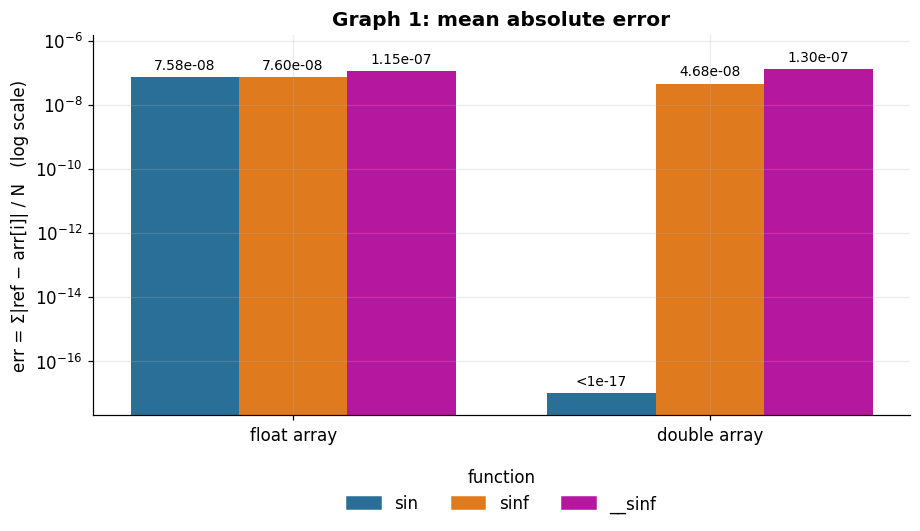

In [ ]:
grouped_bars("err", "err = Σ|ref − arr[i]| / N   (log scale)",
             "Graph 1: mean absolute error", "{:.2e}", log=True, fname="g1_error.png")

### Cell 7: Graph 2, kernel running time
**What to look for:** `__sinf` is expected to be fastest (one hardware instruction). Double `sin` is expected to be much slower on a T4 or GeForce card, because their double-precision throughput is only 1/32 to 1/64 of single precision. The whiskers show how stable the 5 timed runs were.

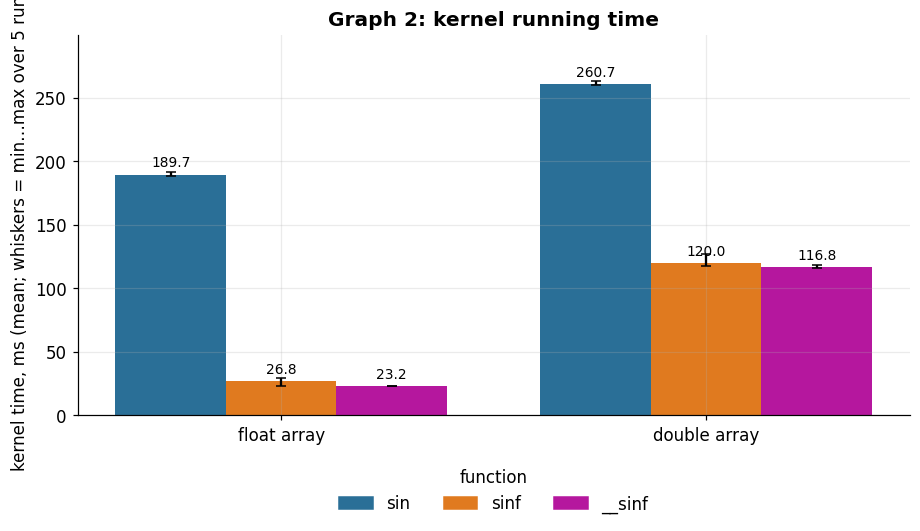

In [ ]:
grouped_bars("mean_ms", "kernel time, ms (mean; whiskers = min…max over 5 runs)",
             "Graph 2: kernel running time", "{:.1f}", whiskers=True, fname="g2_time.png")

### Cell 8: Graph 3, speed vs. accuracy
**What to look for:** each point is one variant (circle = float array, square = double array). The best variant is bottom-left (fast and accurate). Points far to the right are slow; points high up are inaccurate.

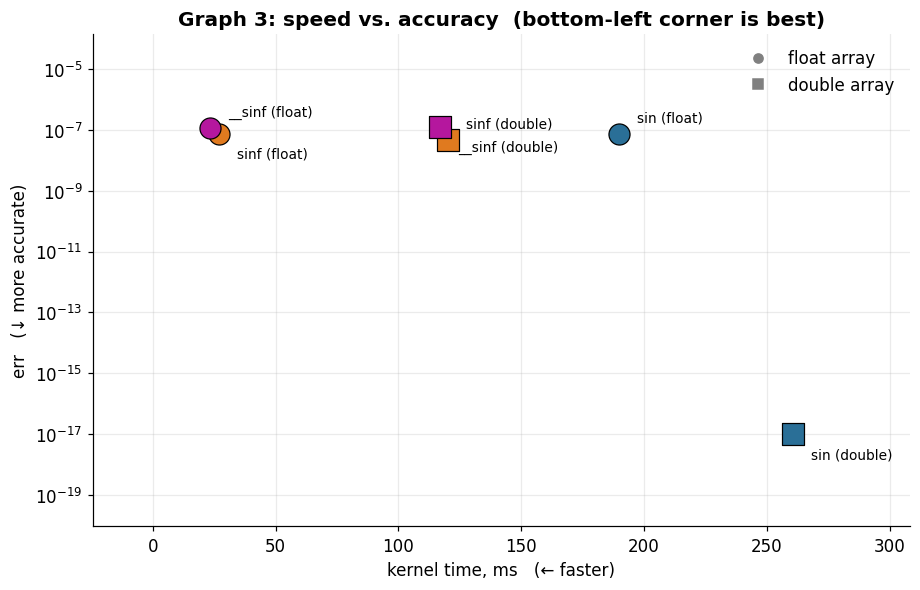

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
marker = {"float": "o", "double": "s"}
for idx, (_, r) in enumerate(res.iterrows()):
    ax.scatter(r["mean_ms"], max(r["err"], FLOOR), s=190, marker=marker[r["type"]],
               color=COLORS[r["func"]], edgecolor="black", lw=0.8, zorder=3)
    ax.annotate(f'{r["func"]} ({r["type"]})', (r["mean_ms"], max(r["err"], FLOOR)),
                xytext=(12, 8 if idx % 2 == 0 else -16), textcoords="offset points", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("kernel time, ms   (← faster)")
ax.set_ylabel("err   (↓ more accurate)")
ax.set_title("Graph 3: speed vs. accuracy  (bottom-left corner is best)", fontweight="bold")
ax.margins(x=0.2, y=0.3)
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color="gray", label="float array"),
                   plt.Line2D([], [], marker="s", ls="", color="gray", label="double array")],
          frameon=False, loc="best")
fig.tight_layout(); fig.savefig("g3_tradeoff.png", dpi=160, bbox_inches="tight"); plt.show()

### Cell 9: Graph 4, effective bandwidth
**What to look for:** the kernel writes 4 GB (float) or 8 GB (double). If a variant reaches a bandwidth close to the GPU's peak, it is memory-bound and the choice of function barely matters. If it is far below peak, arithmetic is the bottleneck (typically double `sin`).

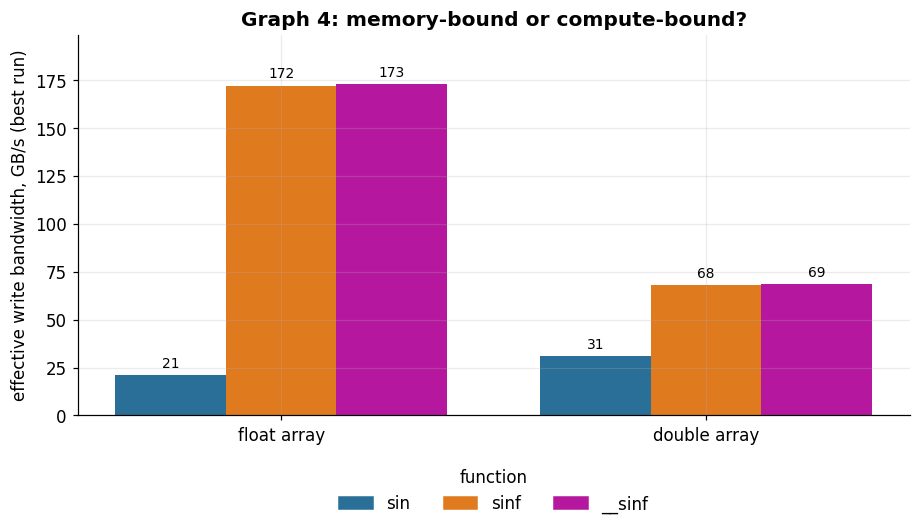

Compare with your GPU's peak memory bandwidth (T4: ~320 GB/s).


In [ ]:
grouped_bars("gbps", "effective write bandwidth, GB/s (best run)",
             "Graph 4: memory-bound or compute-bound?", "{:.0f}", fname="g4_bandwidth.png")
print("Compare with your GPU's peak memory bandwidth (T4: ~320 GB/s).")

### Cell 10: Graph 5, error per angle (float array)
**What to look for:** this explains *why* the errors in Graph 1 differ. `__sinf` should jump up for angles above 180° (shaded), where the argument is larger than π; `sin` and `sinf` should follow each other closely.

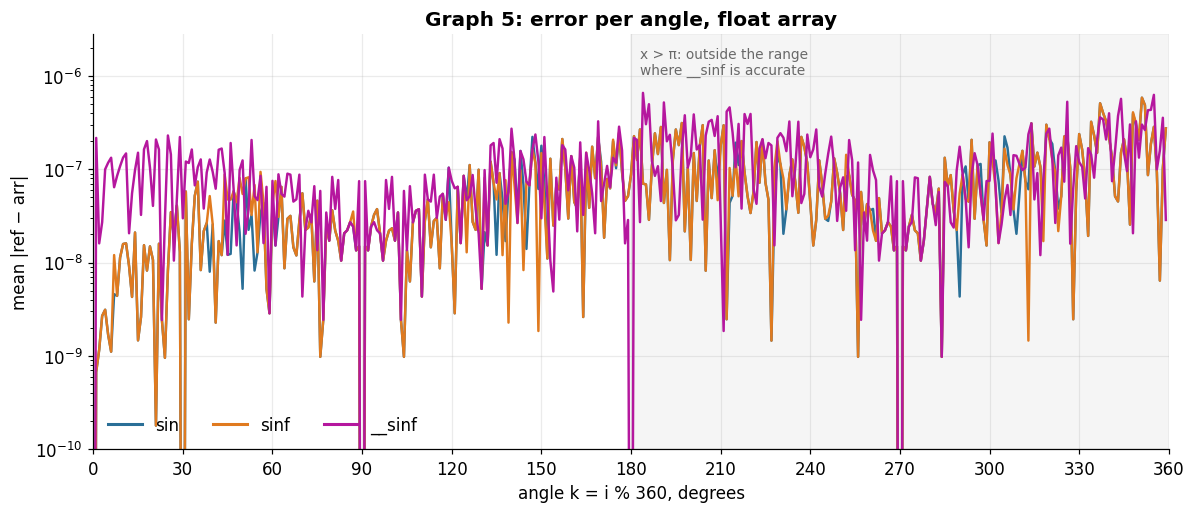

In [ ]:
t = "float"
if t not in TYPES:
    print("no float data (that type was skipped, probably not enough memory)")
else:
    fig, ax = plt.subplots(figsize=(11, 4.8))
    for f in FUNCS:
        d = ang[(ang.type == t) & (ang.func == f)].sort_values("angle")
        ax.semilogy(d["angle"], d["mean_abs_err"].clip(lower=2e-19), color=COLORS[f], lw=1.6, label=f)
    ax.axvspan(180, 360, color="gray", alpha=0.08)
    ax.text(183, 0.97, "x > π: outside the range\nwhere __sinf is accurate",
            transform=ax.get_xaxis_transform(), fontsize=9, color="dimgray", va="top")
    ax.set_ylim(bottom=1e-10 if t == "float" else 1e-19)   # dips below = angles where the result is exact
    ax.set_xlim(0, 359); ax.set_xticks(range(0, 361, 30))
    ax.set_xlabel("angle k = i % 360, degrees"); ax.set_ylabel("mean |ref − arr|")
    ax.set_title("Graph 5: error per angle, float array", fontweight="bold")
    ax.legend(handles=[plt.Line2D([], [], color=COLORS[f], lw=2, label=f) for f in FUNCS],
              frameon=False, ncol=3, loc="lower left")   # explicit handles: matplotlib hides labels that start with "_"
    fig.tight_layout(); fig.savefig("g5_angle_float.png", dpi=160, bbox_inches="tight"); plt.show()

### Cell 11: Graph 6, error per angle (double array)
**What to look for:** `sin` should sit far below the others (near the double-precision limit), while `sinf` and `__sinf` stay at float level even though the array is double. A line running along the very bottom edge means that error is exactly 0.

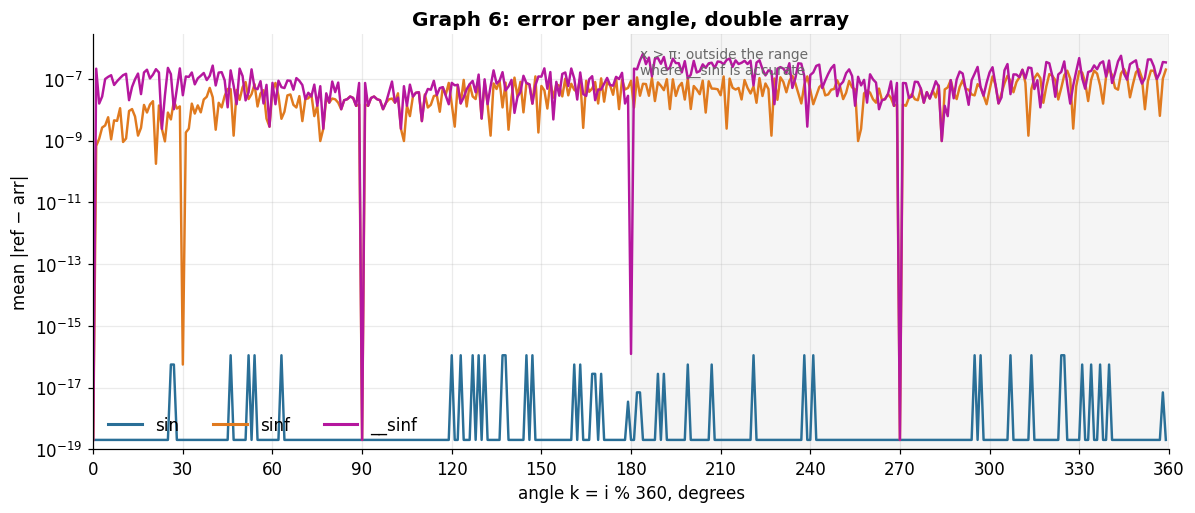

In [ ]:
t = "double"
if t not in TYPES:
    print("no double data (that type was skipped, probably not enough memory)")
else:
    fig, ax = plt.subplots(figsize=(11, 4.8))
    for f in FUNCS:
        d = ang[(ang.type == t) & (ang.func == f)].sort_values("angle")
        ax.semilogy(d["angle"], d["mean_abs_err"].clip(lower=2e-19), color=COLORS[f], lw=1.6, label=f)
    ax.axvspan(180, 360, color="gray", alpha=0.08)
    ax.text(183, 0.97, "x > π: outside the range\nwhere __sinf is accurate",
            transform=ax.get_xaxis_transform(), fontsize=9, color="dimgray", va="top")
    ax.set_ylim(bottom=1e-10 if t == "float" else 1e-19)   # dips below = angles where the result is exact
    ax.set_xlim(0, 359); ax.set_xticks(range(0, 361, 30))
    ax.set_xlabel("angle k = i % 360, degrees"); ax.set_ylabel("mean |ref − arr|")
    ax.set_title("Graph 6: error per angle, double array", fontweight="bold")
    ax.legend(handles=[plt.Line2D([], [], color=COLORS[f], lw=2, label=f) for f in FUNCS],
              frameon=False, ncol=3, loc="lower left")   # explicit handles: matplotlib hides labels that start with "_"
    fig.tight_layout(); fig.savefig("g6_angle_double.png", dpi=160, bbox_inches="tight"); plt.show()

### Cell 12: results table
All the numbers behind the graphs.

In [ ]:
show = res.copy()
show["err"] = show["err"].map("{:.3e}".format)
show["max_abs_err"] = show["max_abs_err"].map("{:.3e}".format)
for c in ["mean_ms", "min_ms", "max_ms", "gbps"]:
    show[c] = show[c].map("{:.2f}".format)
show

,type,func,mean_ms,min_ms,max_ms,err,max_abs_err,gbps
0,float,sin,189.69,188.66,191.42,7.583e-08,5.847e-07,21.20
1,float,sinf,26.83,23.22,29.67,7.599e-08,5.847e-07,172.29
2,float,__sinf,23.22,23.14,23.29,1.148e-07,6.588e-07,172.86
3,double,sin,260.67,259.98,263.10,8.780e-18,1.110e-16,30.77
4,double,sinf,120.00,117.52,126.73,4.679e-08,2.193e-07,68.07
5,double,__sinf,116.79,116.32,118.12,1.301e-07,6.588e-07,68.78
